# RL Environment Diagnostics Notebook

**Purpose:** Systematically test that your RoboSuite Lift environment is learnable before blaming your RL algorithm.

## Debugging Hierarchy
1. **Env API correctness** — spaces, dtypes, shapes, gymnasium compliance
2. **Observation statistics** — scales, NaNs, distributions
3. **Reward analysis** — magnitude, sparsity, component breakdown
4. **Random policy baseline** — what does uniform random achieve?
5. **Scripted/heuristic policy** — can a hard-coded controller solve it?
6. **Short SAC sanity run** — does Q-value / reward trend upward at all?

If step 5 fails → the bug is in the env/controller/reward.  
If step 5 works but step 6 doesn't → the bug is in hyperparameters/reward scale/obs normalization.

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Path setup
ROOT = os.path.dirname(os.path.abspath('.'))
ROBO_PATH = os.path.join(ROOT, 'rl_autonomy', '..', 'external_pkgs', 'RoboSuite')
# Adjust if needed:
ROBO_PATH = os.path.abspath(os.path.join(os.getcwd(), '..', 'external_pkgs', 'RoboSuite'))
if os.path.exists(ROBO_PATH) and ROBO_PATH not in sys.path:
    sys.path.insert(0, ROBO_PATH)

# Also add current dir so we can import flat_sac_baseline
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

print(f'RoboSuite path: {ROBO_PATH}')
print(f'Exists: {os.path.exists(ROBO_PATH)}')

RoboSuite path: /LearnFlake/src/external_pkgs/RoboSuite
Exists: True


/usr/local/lib/python3.10/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


---
## 1. Environment API Sanity Check
Verify spaces, dtypes, shapes, and gymnasium compliance.

In [2]:
from flat_sac_baseline import RoboSuiteLiftGym
import gymnasium as gym

env = RoboSuiteLiftGym()

print('=== Space Checks ===')
print(f'Observation space: {env.observation_space}')
print(f'  shape: {env.observation_space.shape}')
print(f'  dtype: {env.observation_space.dtype}')
print(f'  low:   {env.observation_space.low[:5]}...')
print(f'  high:  {env.observation_space.high[:5]}...')
print()
print(f'Action space: {env.action_space}')
print(f'  shape: {env.action_space.shape}')
print(f'  dtype: {env.action_space.dtype}')
print(f'  low:   {env.action_space.low}')
print(f'  high:  {env.action_space.high}')
print()

# Test reset
obs, info = env.reset()
print(f'Reset obs shape: {obs.shape}, dtype: {obs.dtype}')
print(f'Reset info keys: {list(info.keys())}')
assert env.observation_space.contains(obs), 'ERROR: obs not in observation_space!'
print('✓ Reset obs is within observation_space bounds')

# Test step
action = env.action_space.sample()
obs2, reward, terminated, truncated, info2 = env.step(action)
print(f'\nStep obs shape: {obs2.shape}, dtype: {obs2.dtype}')
print(f'reward={reward:.4f}, terminated={terminated}, truncated={truncated}')
print(f'Step info keys: {list(info2.keys())}')
assert env.observation_space.contains(obs2), 'ERROR: step obs not in observation_space!'
print('✓ Step obs is within observation_space bounds')

print(f'\n=== Gymnasium check_env ===')
try:
    from stable_baselines3.common.env_checker import check_env
    check_env(env, warn=True)
    print('✓ SB3 check_env passed')
except Exception as e:
    print(f'✗ check_env FAILED: {e}')

env.close()

[robosuite WARNING] No private macro file found! (macros.py:57)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:58)
[robosuite WARNING] To setup, run: python /LearnFlake/src/rl_autonomy/../external_pkgs/RoboSuite/robosuite/scripts/setup_macros.py (macros.py:59)
[robosuite INFO] Loading controller configuration from: /LearnFlake/src/rl_autonomy/../external_pkgs/RoboSuite/robosuite/controllers/config/robots/default_rover2026.json (composite_controller_factory.py:121)


=== Space Checks ===
Observation space: Box(-inf, inf, (27,), float32)
  shape: (27,)
  dtype: float32
  low:   [-inf -inf -inf -inf -inf]...
  high:  [inf inf inf inf inf]...

Action space: Box(-1.0, 1.0, (7,), float32)
  shape: (7,)
  dtype: float32
  low:   [-1. -1. -1. -1. -1. -1. -1.]
  high:  [1. 1. 1. 1. 1. 1. 1.]

Reset obs shape: (27,), dtype: float32
Reset info keys: []
✓ Reset obs is within observation_space bounds

Step obs shape: (27,), dtype: float32
reward=0.0000, terminated=False, truncated=False
Step info keys: []
✓ Step obs is within observation_space bounds

=== Gymnasium check_env ===


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


✓ SB3 check_env passed


---
## 2. Observation Statistics
Run N random episodes and gather observation statistics.  
**What to look for:**
- Features with wildly different scales (e.g., one dim in [-3, 3], another in [-0.001, 0.001])
- NaN or Inf values
- Constant features (zero variance — useless information)

In [3]:
env = RoboSuiteLiftGym()
N_EPISODES = 5
MAX_STEPS = 400

all_obs = []
all_rewards = []
all_actions = []

for ep in range(N_EPISODES):
    obs, _ = env.reset()
    ep_obs = [obs]
    ep_rewards = []
    for step in range(MAX_STEPS):
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        ep_obs.append(obs)
        ep_rewards.append(reward)
        all_actions.append(action)
        if terminated or truncated:
            break
    all_obs.extend(ep_obs)
    all_rewards.extend(ep_rewards)
    print(f'Ep {ep+1}: {len(ep_obs)} steps, total_reward={sum(ep_rewards):.1f}')

env.close()

all_obs = np.array(all_obs)
all_rewards = np.array(all_rewards)
all_actions = np.array(all_actions)

print(f'\nCollected {len(all_obs)} observations across {N_EPISODES} episodes')
print(f'Obs shape: {all_obs.shape}')

[robosuite INFO] Loading controller configuration from: /LearnFlake/src/rl_autonomy/../external_pkgs/RoboSuite/robosuite/controllers/config/robots/default_rover2026.json (composite_controller_factory.py:121)


Ep 1: 401 steps, total_reward=0.4
Ep 2: 401 steps, total_reward=0.1
Ep 3: 401 steps, total_reward=0.0
Ep 4: 401 steps, total_reward=0.0
Ep 5: 401 steps, total_reward=0.3

Collected 2005 observations across 5 episodes
Obs shape: (2005, 27)


In [4]:
# --- Observation Feature Analysis ---
obs_mean = np.mean(all_obs, axis=0)
obs_std = np.std(all_obs, axis=0)
obs_min = np.min(all_obs, axis=0)
obs_max = np.max(all_obs, axis=0)
obs_range = obs_max - obs_min

print('=== Per-Feature Statistics ===')
print(f'{"Dim":>4} {"Mean":>10} {"Std":>10} {"Min":>10} {"Max":>10} {"Range":>10}  Flags')
print('-' * 75)

# Map dims to obs keys for readability
OBS_KEYS = [
    'robot0_joint_pos', 'robot0_joint_vel', 'robot0_eef_pos',
    'robot0_eef_quat', 'robot0_gripper_qpos', 'cube_pos', 'gripper_to_cube_pos',
]

flags = []
for i in range(all_obs.shape[1]):
    f = []
    if np.any(np.isnan(all_obs[:, i])):
        f.append('NaN!')
    if np.any(np.isinf(all_obs[:, i])):
        f.append('Inf!')
    if obs_std[i] < 1e-6:
        f.append('CONST')
    if obs_range[i] > 10:
        f.append('LARGE_RANGE')
    if obs_range[i] < 0.001 and obs_std[i] > 0:
        f.append('TINY_RANGE')
    flag_str = ', '.join(f) if f else ''
    flags.append(flag_str)
    print(f'{i:4d} {obs_mean[i]:10.4f} {obs_std[i]:10.4f} {obs_min[i]:10.4f} {obs_max[i]:10.4f} {obs_range[i]:10.4f}  {flag_str}')

print(f'\n=== Summary ===')
print(f'NaN dims:        {sum(1 for f in flags if "NaN" in f)}')
print(f'Inf dims:        {sum(1 for f in flags if "Inf" in f)}')
print(f'Constant dims:   {sum(1 for f in flags if "CONST" in f)}')
print(f'Large range:     {sum(1 for f in flags if "LARGE" in f)}')
print(f'Tiny range:      {sum(1 for f in flags if "TINY" in f)}')
print(f'\nOverall obs range: [{all_obs.min():.4f}, {all_obs.max():.4f}]')
print(f'If features have very different scales, you NEED observation normalization!')

=== Per-Feature Statistics ===
 Dim       Mean        Std        Min        Max      Range  Flags
---------------------------------------------------------------------------
   0    -1.5952     0.1944    -2.0092    -1.1252     0.8841  
   1    -1.6814     0.1928    -2.3300    -1.3630     0.9670  
   2     0.8548     0.2261     0.3383     1.2658     0.9275  
   3    -0.0468     0.2321    -0.7072     0.4763     1.1835  
   4     1.2168     0.1752     0.8658     1.8502     0.9844  
   5    -0.0617     0.2404    -0.6003     0.6302     1.2305  
   6    -0.0002     0.2736    -0.5040     0.4957     0.9997  
   7    -0.0022     0.2800    -0.5146     0.5012     1.0158  
   8    -0.0016     0.2884    -0.5109     0.5461     1.0570  
   9    -0.0024     0.2887    -0.5048     0.5764     1.0812  
  10     0.0059     0.2632    -0.6409     0.9607     1.6016  
  11    -0.0002     0.2763    -0.5753     0.5491     1.1244  
  12     0.2388     0.0799    -0.0382     0.4280     0.4662  
  13     0.2812     

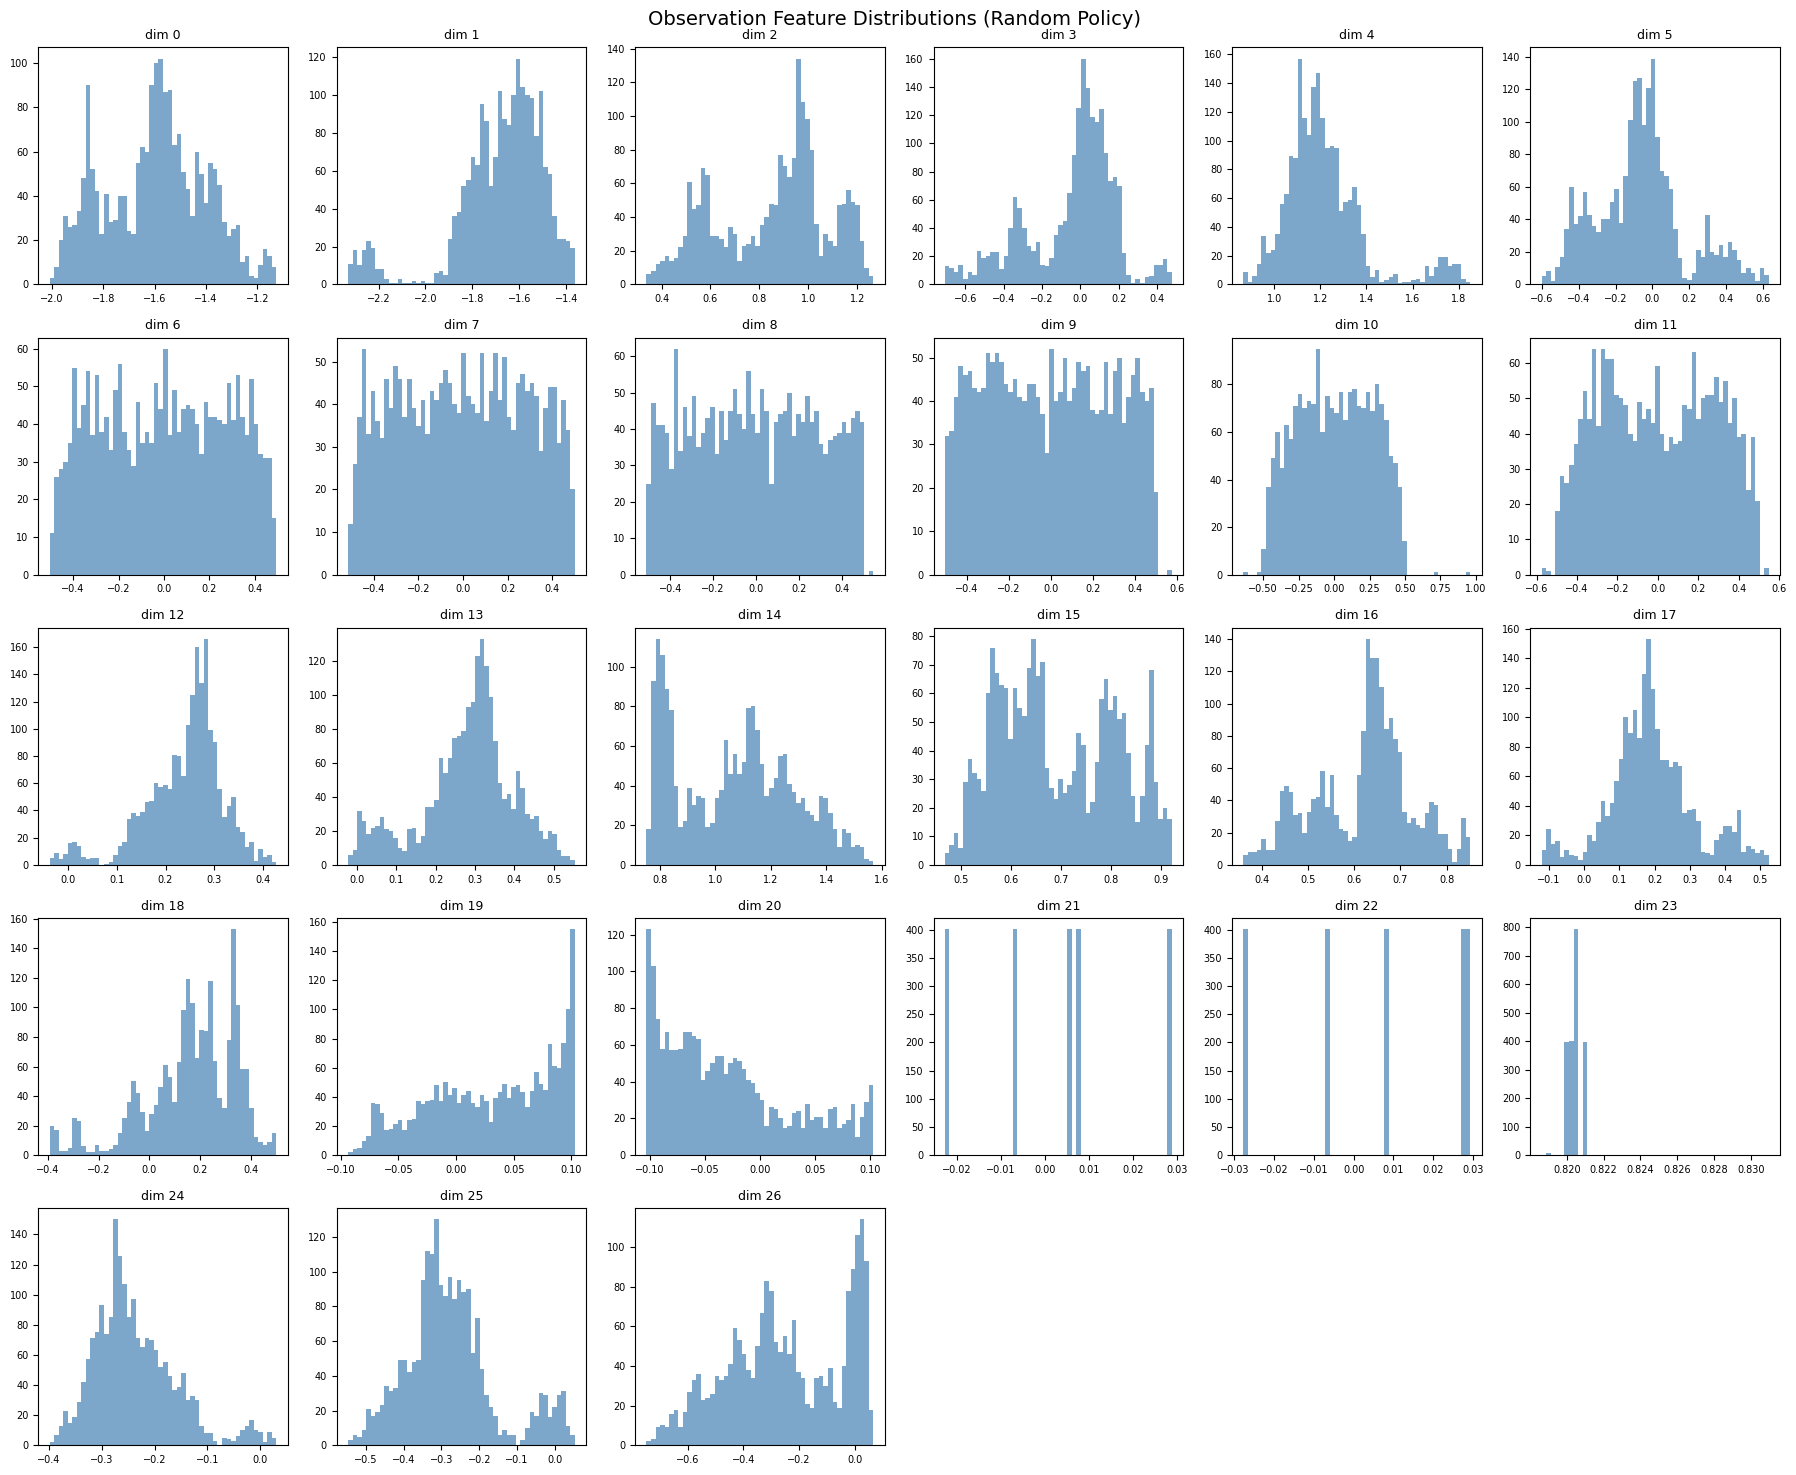

In [5]:
# --- Visualize observation distributions ---
n_dims = all_obs.shape[1]
n_cols = 6
n_rows = (n_dims + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3 * n_rows))
axes = axes.flatten()

for i in range(n_dims):
    axes[i].hist(all_obs[:, i], bins=50, alpha=0.7, color='steelblue')
    axes[i].set_title(f'dim {i}', fontsize=9)
    axes[i].tick_params(labelsize=7)

for i in range(n_dims, len(axes)):
    axes[i].set_visible(False)

fig.suptitle('Observation Feature Distributions (Random Policy)', fontsize=14)
plt.tight_layout()
plt.show()

---
## 3. Reward Analysis
This is the **most important section**. If rewards are too large, too sparse, or have bad gradients, SAC will fail.

In [ ]:
print('=== Reward Statistics (Random Policy) ===')
print(f'Mean:   {all_rewards.mean():.4f}')
print(f'Std:    {all_rewards.std():.4f}')
print(f'Min:    {all_rewards.min():.4f}')
print(f'Max:    {all_rewards.max():.4f}')
print(f'Median: {np.median(all_rewards):.4f}')
print(f'% positive: {(all_rewards > 0).mean() * 100:.1f}%')
print(f'% zero:     {(all_rewards == 0).mean() * 100:.1f}%')
print(f'% negative: {(all_rewards < 0).mean() * 100:.1f}%')
print()

# KEY CHECK: If mean reward is huge or std is huge, SAC Q-values will diverge
if all_rewards.std() > 50:
    print('⚠️  WARNING: Reward std is very high! SAC Q-values may diverge.')
    print('   Consider dividing rewards by a constant (e.g., reward / 100).')
if all_rewards.max() > 100:
    print('⚠️  WARNING: Max reward is very high! This causes instability.')
if abs(all_rewards.mean()) > 50:
    print('⚠️  WARNING: Mean reward is far from 0. Consider centering.')

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Histogram
axes[0].hist(all_rewards, bins=100, alpha=0.7, color='coral')
axes[0].axvline(all_rewards.mean(), color='red', linestyle='--', label=f'mean={all_rewards.mean():.1f}')
axes[0].set_title('Reward Distribution')
axes[0].legend()

# Time series (first episode)
ep_len = min(400, len(all_rewards))
axes[1].plot(all_rewards[:ep_len], alpha=0.8, linewidth=0.5)
axes[1].set_title('Reward Over Time (First Episode)')
axes[1].set_xlabel('Step')

# Cumulative reward
axes[2].plot(np.cumsum(all_rewards[:ep_len]), alpha=0.8)
axes[2].set_title('Cumulative Reward (First Episode)')
axes[2].set_xlabel('Step')

plt.tight_layout()
plt.show()

---
## 4. Scripted Policy Test
**This is the gold standard test.** If a hand-coded controller can't solve it, SAC never will.  
We write a simple 3-phase heuristic: reach → grasp → lift.

In [ ]:
import robosuite as suite
from robosuite.controllers.composite.composite_controller_factory import (
    refactor_composite_controller_config,
)

def scripted_lift_test(n_episodes=5, max_steps=400, verbose=True):
    """
    Test with a scripted (heuristic) policy.
    Uses raw robosuite env (not gym wrapper) for full access to obs.
    """
    arm_cfg = suite.load_part_controller_config(default_controller='JOINT_VELOCITY')
    ctrl_cfg = refactor_composite_controller_config(arm_cfg, 'Rover2026', ['right'])

    env = suite.make(
        env_name='Lift',
        robots=['Rover2026'],
        controller_configs=ctrl_cfg,
        has_renderer=False,
        has_offscreen_renderer=False,
        ignore_done=False,
        use_camera_obs=False,
        control_freq=20,
        horizon=max_steps,
        reward_shaping=True,
    )

    results = []
    action_dim = env.action_dim

    for ep in range(n_episodes):
        obs = env.reset()
        total_reward = 0
        max_height = 0
        success = False
        
        for step in range(max_steps):
            # Get key observations
            eef_pos = obs['robot0_eef_pos']
            cube_pos = obs['cube_pos']
            gripper_to_cube = obs['gripper_to_cube_pos']
            distance = np.linalg.norm(gripper_to_cube)
            gripper_qpos = obs['robot0_gripper_qpos']
            
            action = np.zeros(action_dim)
            
            # Simple 3-phase heuristic:
            # The action maps to joint velocities. For a Cartesian-like
            # control, we'd need IK. Instead, let's just test if the
            # env is responsive AT ALL by printing obs changes.
            
            # Phase 1: Open gripper, move toward cube
            if distance > 0.06:
                # Move end-effector toward cube (rough direction via gripper_to_cube)
                # Since we're in joint velocity space, we can try a simple Jacobian-free
                # approach: just command small random actions and see what happens
                # For a REAL scripted test, you'd use the OSC controller instead.
                direction = gripper_to_cube / (distance + 1e-6)
                # Map Cartesian direction to first 3 joint velocities (rough approximation)
                action[:3] = direction * 0.5
                # Open gripper
                if action_dim > 6:
                    action[6] = -1.0  # open
            # Phase 2: Close gripper
            elif distance <= 0.06 and np.mean(gripper_qpos) > 0.01:
                action[:3] = 0.0  # stop moving
                if action_dim > 6:
                    action[6] = 1.0  # close
            # Phase 3: Lift
            else:
                action[1] = 0.5  # try to move up (approximate)
                if action_dim > 6:
                    action[6] = 1.0  # keep closed
            
            obs, reward, done, info = env.step(action)
            total_reward += reward
            
            height = max(0, obs['cube_pos'][2] - 0.82)
            max_height = max(max_height, height)
            
            if height > 0.05:
                success = True
            
            if done:
                break
        
        results.append({
            'reward': total_reward,
            'max_height': max_height,
            'success': success,
            'steps': step + 1,
        })
        if verbose:
            status = '✓ SUCCESS' if success else '✗ FAILED'
            print(f'  Ep {ep+1}: reward={total_reward:.1f}, max_height={max_height:.4f}m, '
                  f'steps={step+1} {status}')
    
    env.close()
    return results

print('=== Scripted Policy Test (Joint Velocity - rough heuristic) ===')
print('NOTE: Joint velocity control makes scripted policies hard.')
print('If this fails, try switching to OSC_POSE controller for this test.\n')
results = scripted_lift_test(n_episodes=5)

In [ ]:
# --- Better scripted test: use OSC_POSE controller for Cartesian control ---
# This tests whether the TASK is solvable at all, independent of controller choice.

def scripted_osc_test(n_episodes=5, max_steps=400):
    """Test with OSC_POSE for direct Cartesian control — the 'cheat' test."""
    try:
        arm_cfg = suite.load_part_controller_config(default_controller='OSC_POSE')
        ctrl_cfg = refactor_composite_controller_config(arm_cfg, 'Rover2026', ['right'])
    except Exception as e:
        print(f'OSC_POSE not available for Rover2026: {e}')
        print('This is expected if Rover2026 only supports joint-level control.')
        print('In that case, the joint-velocity scripted test above is your best bet.')
        return None

    env = suite.make(
        env_name='Lift',
        robots=['Rover2026'],
        controller_configs=ctrl_cfg,
        has_renderer=False,
        has_offscreen_renderer=False,
        ignore_done=False,
        use_camera_obs=False,
        control_freq=20,
        horizon=max_steps,
        reward_shaping=True,
    )

    results = []
    action_dim = env.action_dim
    print(f'OSC action dim: {action_dim}')

    for ep in range(n_episodes):
        obs = env.reset()
        total_reward = 0
        max_height = 0
        
        for step in range(max_steps):
            eef_pos = obs['robot0_eef_pos']
            cube_pos = obs['cube_pos']
            delta = cube_pos - eef_pos
            dist = np.linalg.norm(delta)
            
            action = np.zeros(action_dim)
            
            if dist > 0.03:
                # Move toward cube
                action[:3] = delta * 3.0  # P-controller
                action[-1] = -1.0  # open gripper
            elif cube_pos[2] - 0.82 < 0.1:
                # Close gripper and lift
                action[2] = 0.5  # lift up
                action[-1] = 1.0  # close gripper
            else:
                # Hold
                action[-1] = 1.0
            
            obs, reward, done, info = env.step(action)
            total_reward += reward
            h = max(0, obs['cube_pos'][2] - 0.82)
            max_height = max(max_height, h)
            if done:
                break
        
        success = max_height > 0.05
        status = '✓' if success else '✗'
        print(f'  Ep {ep+1}: reward={total_reward:.1f}, height={max_height:.4f}, steps={step+1} {status}')
        results.append({'reward': total_reward, 'max_height': max_height, 'success': success})
    
    env.close()
    return results

print('=== Scripted OSC_POSE Test (Cartesian Control) ===')
osc_results = scripted_osc_test()

---
## 5. Action Effect Test
Does each action dimension actually DO something?  
This catches dead joints, inverted control, or numerical issues.

In [ ]:
env = RoboSuiteLiftGym()

action_dim = env.action_space.shape[0]
print(f'Testing each of {action_dim} action dimensions independently...\n')

for dim in range(action_dim):
    obs, _ = env.reset()
    
    # Apply +1.0 to just this dimension for 20 steps
    obs_before = obs.copy()
    for _ in range(20):
        action = np.zeros(action_dim, dtype=np.float32)
        action[dim] = 1.0
        obs, r, term, trunc, info = env.step(action)
        if term or trunc:
            break
    
    obs_change = np.linalg.norm(obs - obs_before)
    flag = '⚠️ DEAD?' if obs_change < 0.01 else '✓'
    print(f'  Action dim {dim:2d}: obs_change = {obs_change:.4f}  {flag}')

env.close()

---
## 6. Reward Component Breakdown (V3 Wrapper)
If you're using the env_wrapper.py (RoboSuiteEnvV3), this shows how each reward component contributes.  
**Skip this cell** if you're only testing the flat baseline.

In [ ]:
# Uncomment and adjust import if testing V3 wrapper:
# from env_wrapper import RoboSuiteEnvV3 as EnvV3
#
# env = EnvV3(render=False, domain_randomization=False, curriculum_level=0)
#
# ep_infos = []
# obs = env.reset()
# for step in range(400):
#     action = np.random.uniform(-1, 1, env.action_dim).astype(np.float32)
#     obs, reward, done, info = env.step(action)
#     ep_infos.append(info)
#     if done:
#         break
# env.close()
#
# # Plot phase transitions + reward components
# phases = [i['phase'] for i in ep_infos]
# distances = [i['distance'] for i in ep_infos]
# heights = [i['height'] for i in ep_infos]
#
# fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
# axes[0].plot(distances, label='distance to cube')
# axes[0].set_ylabel('Distance (m)')
# axes[0].legend()
#
# axes[1].plot(heights, label='cube height above table')
# axes[1].set_ylabel('Height (m)')
# axes[1].legend()
#
# # Show phase as colored background
# phase_map = {'reach': 0, 'grasp': 1, 'lift': 2, 'hold': 3, 'recover': 4, 'return': 5}
# phase_colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336', '#00BCD4']
# for i, p in enumerate(phases):
#     axes[2].axvspan(i, i+1, alpha=0.3, color=phase_colors[phase_map.get(p, 0)])
# axes[2].set_ylabel('Phase')
# axes[2].set_xlabel('Step')
#
# plt.suptitle('V3 Env: One Episode (Random Policy)')
# plt.tight_layout()
# plt.show()

print('Uncomment the cell above to test V3 wrapper reward components.')

---
## 7. Quick SAC Learning Curve Test
Train SAC for a short run (10-20k steps) and check if the reward trend is *increasing at all*.  
If the curve is **flat** → obs normalization or reward scale issue.  
If the curve **diverges** (goes to -inf or +inf) → reward magnitude too large.

In [ ]:
from stable_baselines3 import SAC
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize

# ======================================================================
# KEY FIX: Use VecNormalize for observation AND reward normalization!
# This is the #1 thing people miss with SAC on custom envs.
# ======================================================================

def make_env():
    return Monitor(RoboSuiteLiftGym())

# Option A: Without normalization (your current setup)
env_raw = DummyVecEnv([make_env])

# Option B: WITH normalization (recommended fix)
env_normed = DummyVecEnv([make_env])
env_normed = VecNormalize(
    env_normed,
    norm_obs=True,        # Normalize observations to ~N(0,1)
    norm_reward=True,     # Normalize rewards to unit variance
    clip_obs=10.0,        # Clip normalized obs
    clip_reward=10.0,     # Clip normalized rewards
    gamma=0.99,           # Discount for reward normalization
)

print('Training two short SAC runs (10k steps each)...')
print('This will take a few minutes.\n')

In [ ]:
# --- Run A: Raw (no normalization) ---
print('Run A: SAC without normalization...')
model_raw = SAC(
    'MlpPolicy', env_raw,
    learning_rate=3e-4,
    buffer_size=50_000,
    batch_size=256,
    learning_starts=500,
    verbose=0,
    device='auto',
)
model_raw.learn(total_timesteps=10_000)

# Get episode rewards from Monitor
raw_rewards = env_raw.get_attr('get_episode_rewards')[0]
print(f'  Episodes completed: {len(raw_rewards)}')
if len(raw_rewards) > 0:
    print(f'  Mean ep reward: {np.mean(raw_rewards):.1f}')
    print(f'  Last 5 ep rewards: {[f"{r:.1f}" for r in raw_rewards[-5:]]}')

env_raw.close()

In [ ]:
# --- Run B: With VecNormalize ---
print('Run B: SAC WITH observation + reward normalization...')
model_normed = SAC(
    'MlpPolicy', env_normed,
    learning_rate=3e-4,
    buffer_size=50_000,
    batch_size=256,
    learning_starts=500,
    verbose=0,
    device='auto',
)
model_normed.learn(total_timesteps=10_000)

# VecNormalize wraps Monitor, so we need to get rewards differently
normed_rewards = env_normed.get_attr('get_episode_rewards')[0]
print(f'  Episodes completed: {len(normed_rewards)}')
if len(normed_rewards) > 0:
    print(f'  Mean ep reward (unnormalized): {np.mean(normed_rewards):.1f}')
    print(f'  Last 5 ep rewards: {[f"{r:.1f}" for r in normed_rewards[-5:]]}')

env_normed.close()

In [ ]:
# --- Compare learning curves ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if len(raw_rewards) > 1:
    axes[0].plot(raw_rewards, alpha=0.4, label='per-episode')
    # Smoothed
    window = min(10, len(raw_rewards))
    smoothed = np.convolve(raw_rewards, np.ones(window)/window, mode='valid')
    axes[0].plot(smoothed, linewidth=2, label=f'smoothed ({window}ep)')
    axes[0].set_title('SAC WITHOUT Normalization')
    axes[0].set_xlabel('Episode')
    axes[0].set_ylabel('Episode Reward')
    axes[0].legend()
else:
    axes[0].text(0.5, 0.5, 'Not enough episodes', ha='center', va='center', transform=axes[0].transAxes)

if len(normed_rewards) > 1:
    axes[1].plot(normed_rewards, alpha=0.4, label='per-episode')
    window = min(10, len(normed_rewards))
    smoothed = np.convolve(normed_rewards, np.ones(window)/window, mode='valid')
    axes[1].plot(smoothed, linewidth=2, label=f'smoothed ({window}ep)')
    axes[1].set_title('SAC WITH VecNormalize (obs + reward)')
    axes[1].set_xlabel('Episode')
    axes[1].set_ylabel('Episode Reward')
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'Not enough episodes', ha='center', va='center', transform=axes[1].transAxes)

plt.suptitle('10k Step SAC Comparison: Raw vs Normalized', fontsize=14)
plt.tight_layout()
plt.show()

print('\nIf neither curve shows ANY upward trend, the environment itself has a bug.')
print('If only the normalized version improves, you just need VecNormalize.')

---
## 8. Terminated/Truncated Bug Check
Your flat_sac_baseline has a logic issue in `step()` that can confuse SB3.

In [ ]:
# Check the terminated/truncated logic
env = RoboSuiteLiftGym()
obs, _ = env.reset()

term_trunc_pairs = []
for step in range(500):  # Past horizon of 400
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    if terminated or truncated:
        term_trunc_pairs.append((terminated, truncated, step+1, info))
        print(f'  Step {step+1}: terminated={terminated}, truncated={truncated}')
        print(f'           info keys: {list(info.keys())}')
        if 'TimeLimit.truncated' in info:
            print(f'           TimeLimit.truncated = {info["TimeLimit.truncated"]}')
        break

env.close()

if term_trunc_pairs:
    t, tr, s, i = term_trunc_pairs[0]
    if t and tr:
        print('\n⚠️  BUG: Both terminated=True AND truncated=True!')
        print('   SB3 treats this as terminated (no bootstrap), losing value estimation.')
        print('   Fix: In step(), if episode ends by horizon, set terminated=False, truncated=True.')
    elif tr and not t:
        print('\n✓ Correct: truncated=True, terminated=False (horizon timeout).')
    elif t and not tr:
        print('\n✓ Episode terminated before horizon (task completion or failure).')
else:
    print('\nEnvironment did not end within 500 steps — check ignore_done setting.')

---
## Summary: What to Do Based on Results

| Symptom | Likely Cause | Fix |
|---------|-------------|-----|
| `check_env` fails | API bug in wrapper | Fix space/dtype/shape issues |
| Obs features have wildly different scales | Missing normalization | Use `VecNormalize(norm_obs=True)` |
| Reward std > 50 or max > 100 | Reward scale too large | Divide rewards by constant, or use `VecNormalize(norm_reward=True)` |
| Reward is 0 for 95%+ of steps | Too sparse | Add denser shaping (you already have this) |
| Both terminated AND truncated = True | Wrapper logic bug | Fix the step() return values |
| Action dims are "dead" | Controller issue | Check joint mapping, controller config |
| Scripted policy can't solve | Env/controller broken | Test with OSC_POSE, check reward sign |
| Random > trained agent | Reward encourages wrong behavior | Simplify reward to just robosuite default |
| SAC reward curve flat | Learning rate too low, or Q-value divergence | Check Q-values in TensorBoard, try `reward / 100` |

### Recommended Libraries
- **`stable_baselines3`** — already using, good
- **`VecNormalize`** from SB3 — **add this, probably your #1 fix**
- **TensorBoard** — `tensorboard --logdir baselines/flat_sac/` for loss/Q-value curves
- **`matplotlib`** — quick plots in this notebook
- **Weights & Biases (`wandb`)** — optional but great for comparing runs
- **`gymnasium.utils.env_checker`** — catches API bugs

### Recommended Workflow
1. Work in **this notebook** for diagnostics and short experiments
2. Once env passes all checks, train long runs via **CLI script** (`flat_sac_baseline.py`)
3. Monitor via **TensorBoard** (add `tensorboard_log=save_dir` to SAC constructor)